# 06 — Multi-Model Comparison Visualization
Visualisasi perbandingan model dari Phase 1 dan Phase 2 results.

In [1]:
import sys, unittest.mock; sys.modules.setdefault('transformers.dependency_versions_check', unittest.mock.MagicMock())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

df_p1_raw = pd.read_csv("phase1_screening_results.csv")
df_p2 = pd.read_csv("phase2_group_results.csv")

# Normalize Phase 1: keep _mean columns, drop _std, rename to lowercase
rename_map = {c: c.lower().replace('_mean', '') for c in df_p1_raw.columns if '_mean' in c}
rename_map.update({'Model': 'Model', 'Covariates': 'Covariates', 'Window': 'Window'})
drop_cols = [c for c in df_p1_raw.columns if '_std' in c.lower()]
df_p1 = df_p1_raw.drop(columns=drop_cols).rename(columns=rename_map)

df_p1['Phase'] = 'Phase1'
df_p2['Phase'] = 'Phase2'
df_all = pd.concat([df_p1, df_p2], ignore_index=True)

print("Phase 1:", len(df_p1), "rows | columns:", df_p1.columns.tolist())
print("Phase 2:", len(df_p2), "rows | columns:", df_p2.columns.tolist())

Phase 1: 128 rows | columns: ['Model', 'Covariates', 'Window', 'mape', 'mae', 'rmse', 'r2', 'da', 'Phase']
Phase 2: 24 rows | columns: ['Model', 'Covariates', 'Window', 'mape', 'mae', 'rmse', 'r2', 'da', 'Phase']


## 1. Best MAPE per Model (Phase 2)

       Model    Covariates  Window   mape    da
  ExtraTrees Sig_Commodity      30 0.5044 54.18
RandomForest Sig_Commodity      30 0.5044 54.18
     XGBoost Sig_Commodity      30 0.5046 53.61


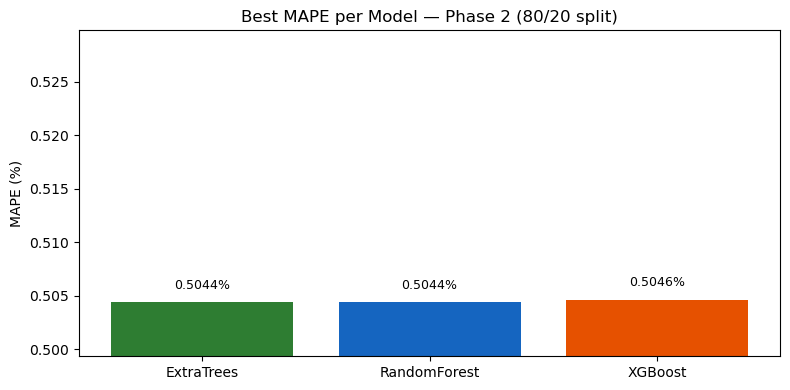

In [2]:

best_per_model = df_p2.sort_values('mape').groupby('Model').first().reset_index()
print(best_per_model[['Model', 'Covariates', 'Window', 'mape', 'da']].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = {'RandomForest': '#1565C0', 'ExtraTrees': '#2E7D32', 'XGBoost': '#E65100', 'LightGBM': '#6A1B9A'}
for _, row in best_per_model.iterrows():
    ax.bar(row['Model'], row['mape'], color=colors.get(row['Model'], 'gray'), label=row['Model'])
    ax.text(row['Model'], row['mape'] + 0.001, f"{row['mape']:.4f}%", ha='center', va='bottom', fontsize=9)
ax.set_ylabel("MAPE (%)")
ax.set_title("Best MAPE per Model — Phase 2 (80/20 split)")
ax.set_ylim(bottom=min(best_per_model['mape']) * 0.99)
plt.tight_layout()
plt.savefig("plot_model_comparison_mape.png", dpi=150, bbox_inches='tight')
plt.show()


## 2. Heatmap: MAPE per Model × Covariate Group (Phase 2)

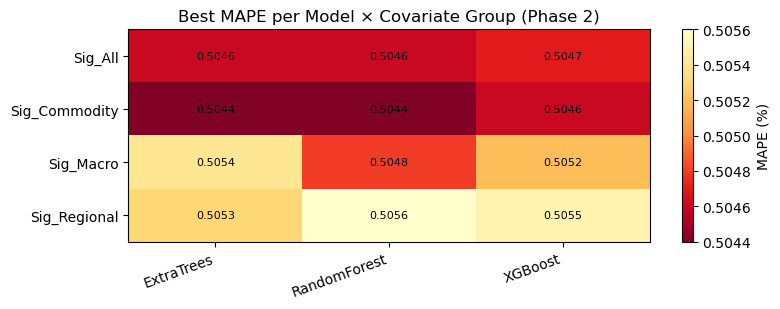

In [3]:

pivot_p2 = df_p2.pivot_table(values='mape', index='Covariates', columns='Model', aggfunc='min')
fig, ax = plt.subplots(figsize=(8, max(3, len(pivot_p2) * 0.8)))
im = ax.imshow(pivot_p2.values, cmap='YlOrRd_r', aspect='auto')
plt.colorbar(im, ax=ax, label='MAPE (%)')
ax.set_xticks(range(len(pivot_p2.columns)))
ax.set_xticklabels(pivot_p2.columns, rotation=20, ha='right')
ax.set_yticks(range(len(pivot_p2.index)))
ax.set_yticklabels(pivot_p2.index)
for i in range(len(pivot_p2.index)):
    for j in range(len(pivot_p2.columns)):
        v = pivot_p2.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.4f}', ha='center', va='center', fontsize=8)
ax.set_title("Best MAPE per Model × Covariate Group (Phase 2)")
plt.tight_layout()
plt.savefig("plot_phase2_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()


## 3. Window Comparison: W30 vs W120

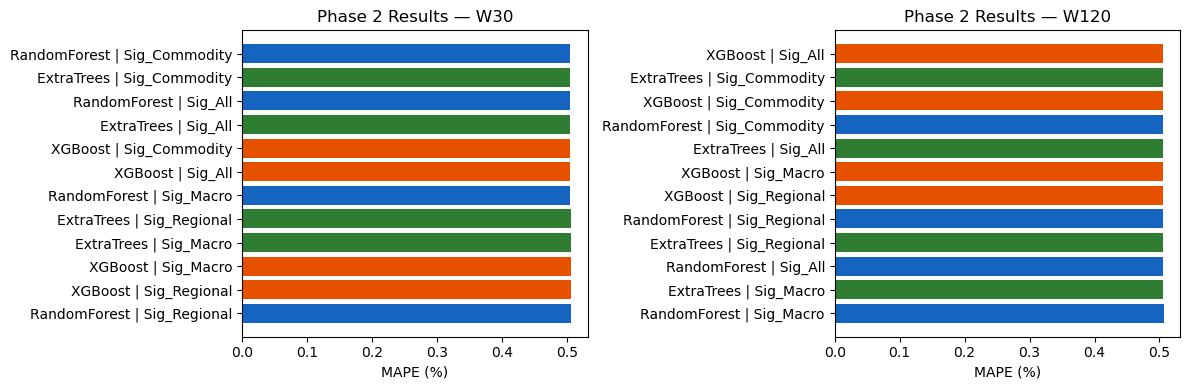

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, window in zip(axes, [30, 120]):
    sub = df_p2[df_p2['Window'] == window].sort_values('mape')
    ax.barh(sub['Model'] + ' | ' + sub['Covariates'], sub['mape'],
            color=[colors.get(m, 'gray') for m in sub['Model']])
    ax.set_xlabel("MAPE (%)")
    ax.set_title(f"Phase 2 Results — W{window}")
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig("plot_window_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


## 4. Directional Accuracy Comparison

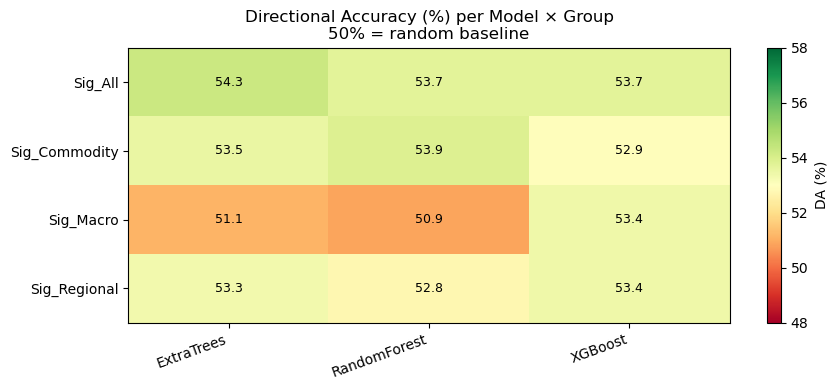

In [5]:

fig, ax = plt.subplots(figsize=(9, 4))
da_pivot = df_p2.pivot_table(values='da', index='Covariates', columns='Model', aggfunc='mean')
da_data = da_pivot.values
im = ax.imshow(da_data, cmap='RdYlGn', aspect='auto', vmin=48, vmax=58)
plt.colorbar(im, ax=ax, label='DA (%)')
ax.set_xticks(range(len(da_pivot.columns)))
ax.set_xticklabels(da_pivot.columns, rotation=20, ha='right')
ax.set_yticks(range(len(da_pivot.index)))
ax.set_yticklabels(da_pivot.index)
for i in range(len(da_pivot.index)):
    for j in range(len(da_pivot.columns)):
        v = da_data[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=9)
ax.set_title("Directional Accuracy (%) per Model × Group\n50% = random baseline")
plt.tight_layout()
plt.savefig("plot_directional_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()


## 5. Summary Table

In [6]:

print("=== TOP 10 CONFIGURATIONS (Phase 2) ===")
top10 = df_p2.sort_values('mape')[['Model','Covariates','Window','mape','rmse','mae','r2','da']].head(10)
print(top10.to_string(index=False))

print("\n=== ALL RESULTS COMBINED ===")
df_all_clean = df_all[['Phase','Model','Covariates','Window','mape','da']].sort_values(['Phase','mape'])
print(df_all_clean.to_string(index=False))


=== TOP 10 CONFIGURATIONS (Phase 2) ===
       Model    Covariates  Window   mape    rmse     mae     r2    da
RandomForest Sig_Commodity      30 0.5044 47.8617 35.8555 0.9720 54.18
  ExtraTrees Sig_Commodity      30 0.5044 47.8198 35.8581 0.9720 54.18
     XGBoost Sig_Commodity      30 0.5046 47.8785 35.8706 0.9719 53.61
  ExtraTrees       Sig_All      30 0.5046 47.8441 35.8723 0.9720 53.99
RandomForest       Sig_All      30 0.5046 47.8647 35.8661 0.9720 54.75
     XGBoost       Sig_All     120 0.5047 47.9177 35.8798 0.9719 53.04
     XGBoost       Sig_All      30 0.5047 47.8732 35.8762 0.9720 54.37
     XGBoost Sig_Commodity     120 0.5048 47.8973 35.8826 0.9719 52.28
RandomForest     Sig_Macro      30 0.5048 47.9133 35.8797 0.9719 52.28
  ExtraTrees Sig_Commodity     120 0.5048 47.8805 35.8855 0.9719 52.85

=== ALL RESULTS COMBINED ===
 Phase        Model      Covariates  Window   mape    da
Phase1   ExtraTrees          Silver      30 0.6581 54.10
Phase1   ExtraTrees            Gold